In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


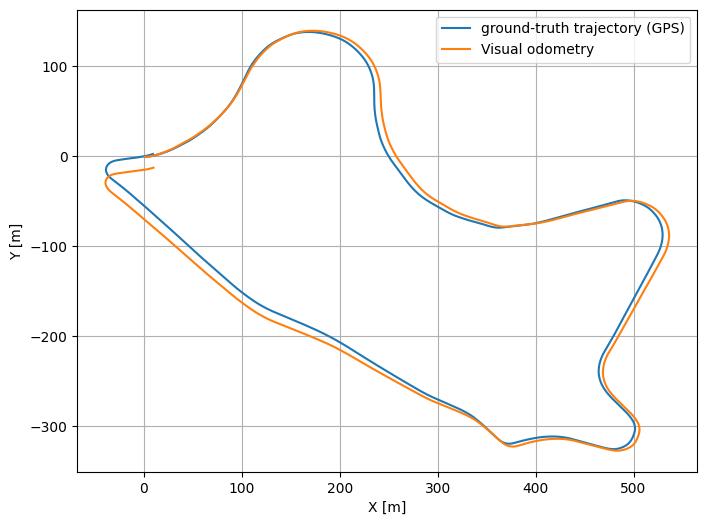

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
kitti_dataset = "0033"
data = DataLoader(sequence_nr=kitti_dataset, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [3]:
x_setup1, P_setup1, H_setup1 = data.get_initial_data(setup=SetupEnum.SETUP_1)
x_setup2, P_setup2, H_setup2 = data.get_initial_data(setup=SetupEnum.SETUP_2)
x_setup3, P_setup3, H_setup3 = data.get_initial_data(setup=SetupEnum.SETUP_3)

alpha_setup1 = 1.0
beta_setup1 = 6.0
kappa_setup1 = 0.0

alpha_setup2 = 0.6
beta_setup2 = 0.0
kappa_setup2 = -7.0

alpha_setup3 = 0.0001
beta_setup3 = 4.0
kappa_setup3 = 0.0

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 16749.70it/s]

[UKF] errors: {<ErrorEnum.MAE: 1>: 13150.807, <ErrorEnum.RMSE: 2>: 14842.428, <ErrorEnum.MAX: 3>: 32971.065}


{<ErrorEnum.MAE: 1>: 13150.807,
 <ErrorEnum.RMSE: 2>: 14842.428,
 <ErrorEnum.MAX: 3>: 32971.065}

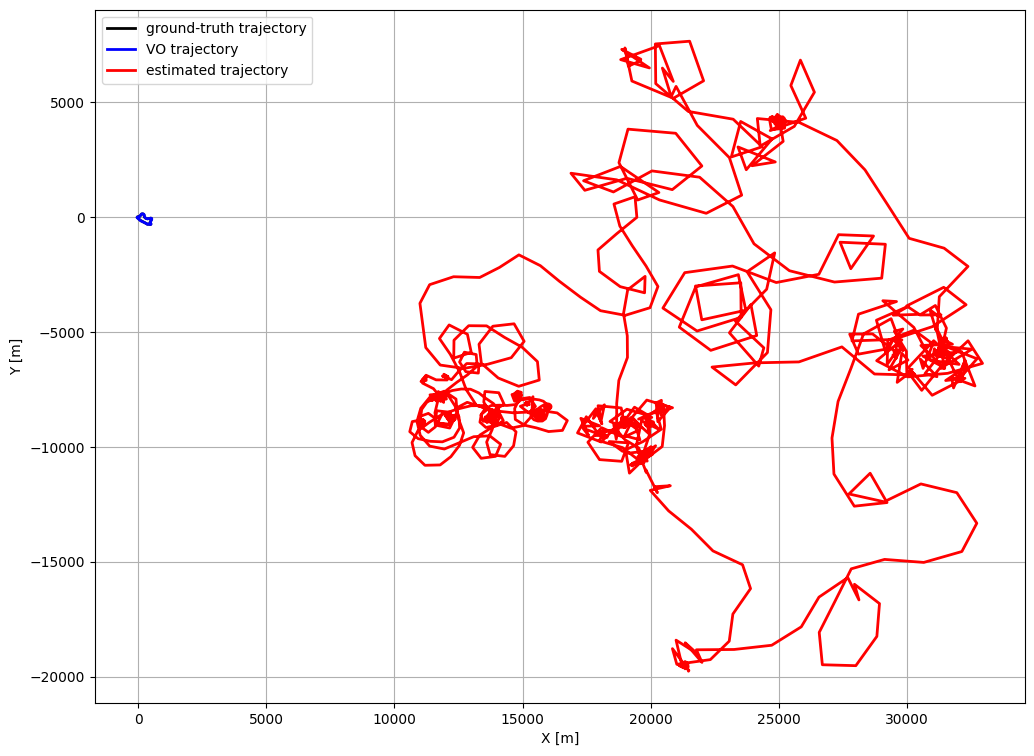

In [8]:
ukf = UnscentedKalmanFilter(x=x_setup3, P=P_setup3, H=H_setup3)
ukf.run(data=data, 
        setup=SetupEnum.SETUP_3,
        measurement_type=MeasurementDataEnum.ALL_DATA, 
        debug_mode=True,
        show_graph=True,
        skip_update=True
       )

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 13983.18it/s]

[EKF] errors: {<ErrorEnum.MAE: 1>: 3932.789, <ErrorEnum.RMSE: 2>: 5950.609, <ErrorEnum.MAX: 3>: 19170.853}


{<ErrorEnum.MAE: 1>: 3932.789,
 <ErrorEnum.RMSE: 2>: 5950.609,
 <ErrorEnum.MAX: 3>: 19170.853}

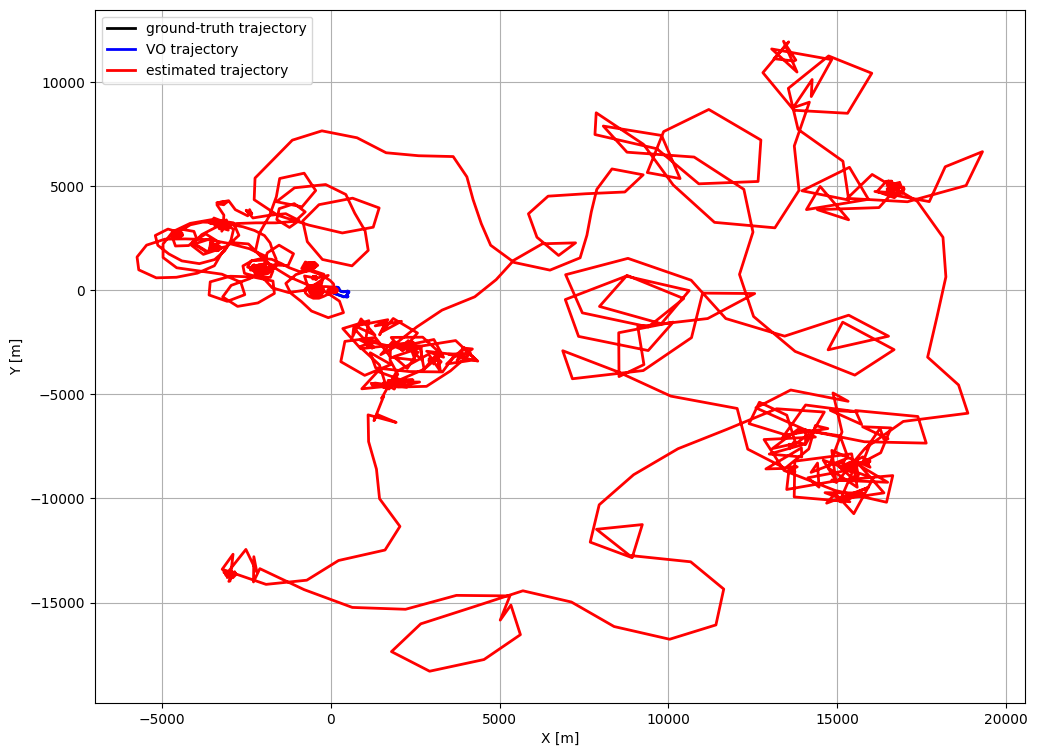

In [7]:
ekf = ExtendedKalmanFilter(x=x_setup3, P=P_setup3, H=H_setup3)
ekf.run(data=data, 
        setup=SetupEnum.SETUP_3,
        measurement_type=MeasurementDataEnum.ALL_DATA, 
        debug_mode=True,
        show_graph=True,
        skip_update=True
       )

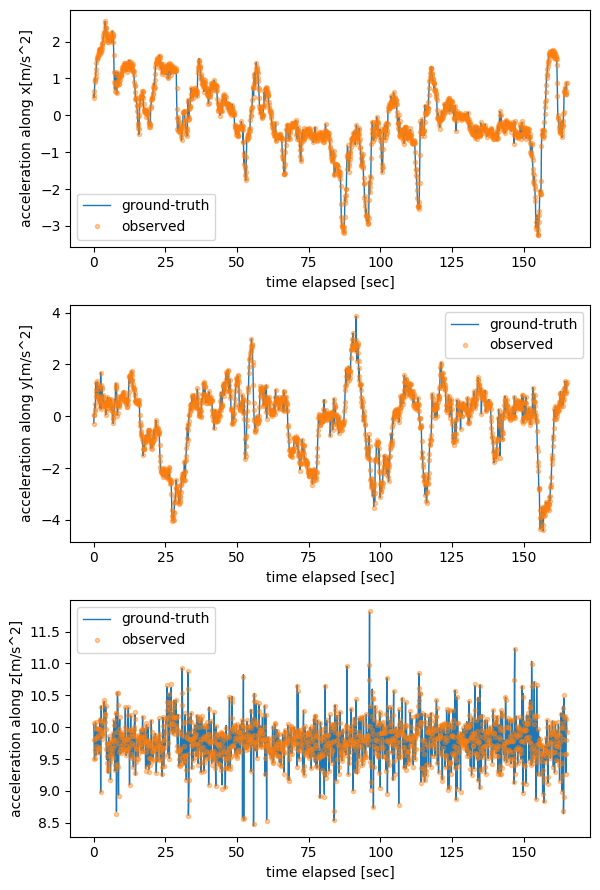

In [9]:
data.show_linear_acceleration_with_noise()

In [13]:
linear_acc = data.IMU_outputs[:, :3].copy()
angular_vel = data.IMU_outputs[:, 3:].copy()

In [23]:
def visualize_data(imu_data, labels):
    fig, ax = plt.subplots(3, 1, figsize=(10, 12))
    
    for idx in range(3):  
        i = idx + 4
        ax[idx].plot(data.ts, imu_data[:, idx:idx+1], lw=1, label='ground-truth')
        ax[idx].set_xlabel('time elapsed [sec]')
        ax[idx].set_ylabel(labels[idx])
        ax[idx].legend()
    fig.tight_layout()

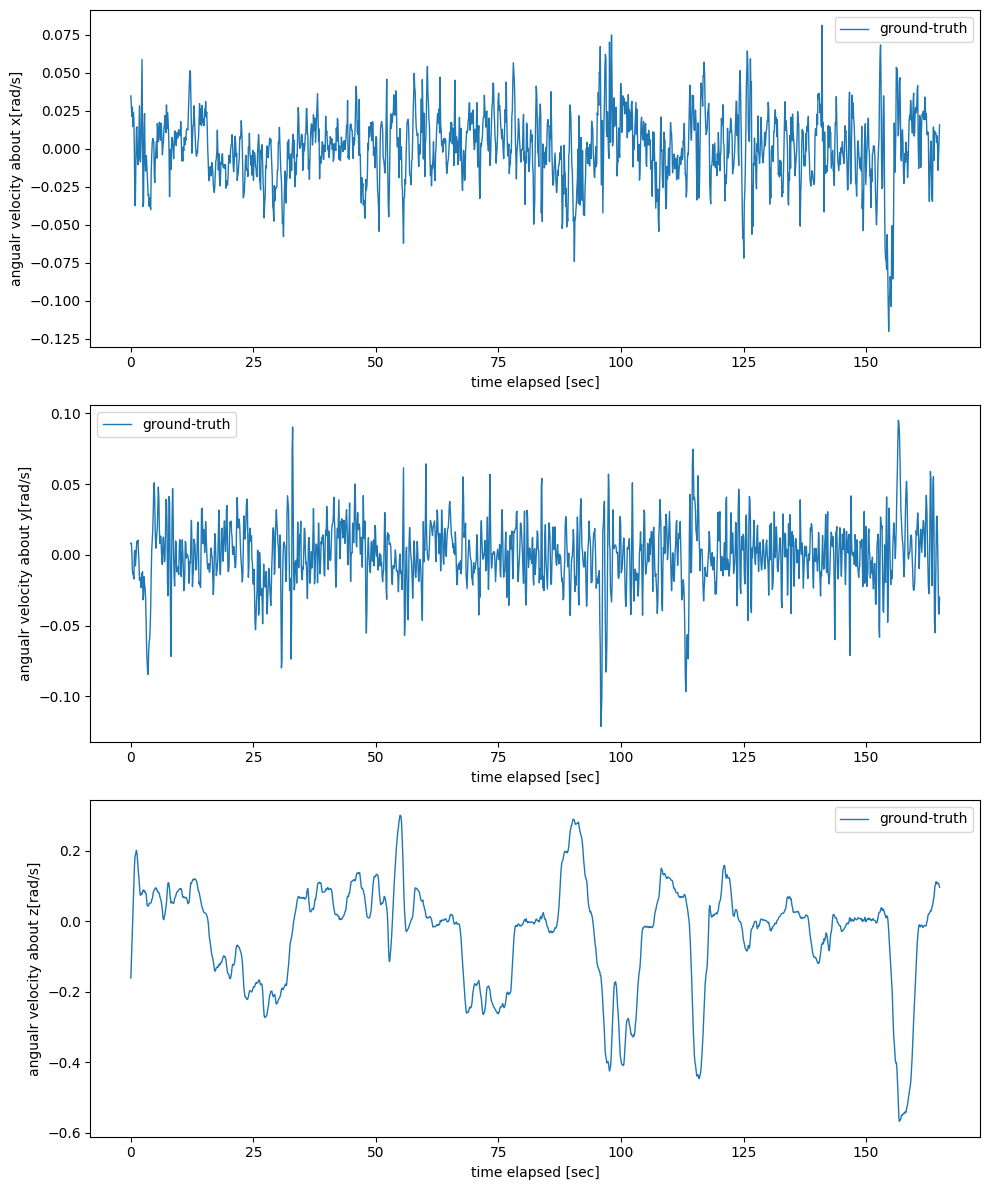

In [25]:
ang_y_labels = ['angualr velocity about x[rad/s]', 
                'angualr velocity about y[rad/s]', 
                'angualr velocity about z[rad/s]']
visualize_data(angular_vel, ang_y_labels)

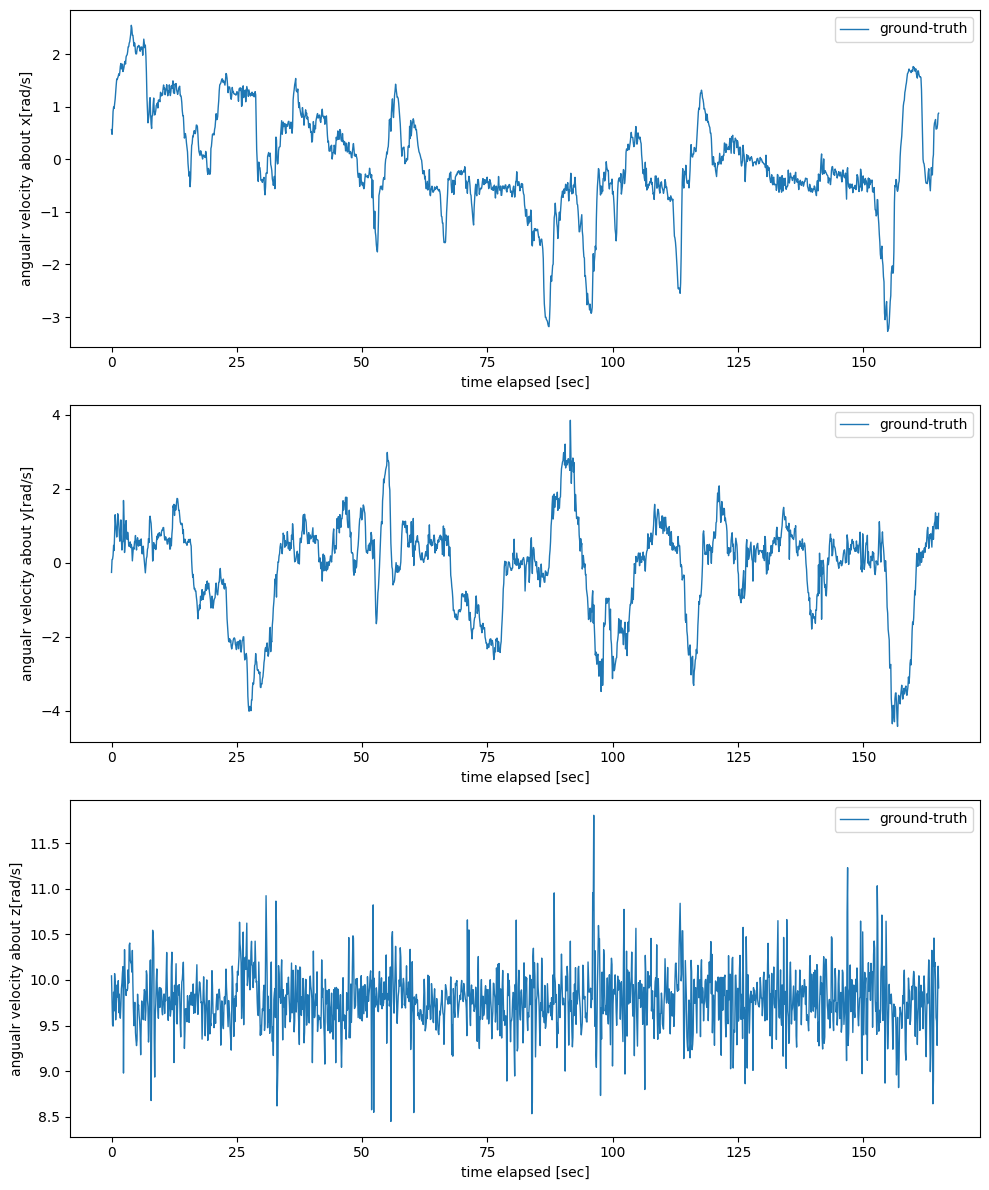

In [26]:
acc_y_labels = ['acceleration along x[m/s^2]', 
                'acceleration along y[m/s^2]', 
                'acceleration along z[m/s^2]']
visualize_data(linear_acc, acc_y_labels)

In [98]:
def get_smoothed_imu_data(window_size=3):
    linear_acc = data.IMU_outputs[:, :3].copy()
    angular_vel = data.IMU_outputs[:, 3:].copy()
    
    linear_df = pd.DataFrame(linear_acc, columns=["acc_x", "acc_y", "acc_z"])
    vel_df = pd.DataFrame(angular_vel, columns=["ang_vel_x", "ang_vel_y", "ang_vel_z"])
    
    linear_rolling_mean = linear_df.rolling(window=window_size).mean()
    vel_rolling_mean = vel_df.rolling(window=window_size).mean()
    
    loc_idx = window_size - 2
    np_idx = window_size - 1
    
    vel_rolling_mean.loc[:loc_idx, "ang_vel_x"] = angular_vel[:np_idx, 0]
    vel_rolling_mean.loc[:loc_idx, "ang_vel_y"] = angular_vel[:np_idx, 1]
    vel_rolling_mean.loc[:loc_idx, "ang_vel_z"] = angular_vel[:np_idx, 2]
    
    linear_rolling_mean.loc[:loc_idx, "acc_x"] = linear_acc[:np_idx, 0]
    linear_rolling_mean.loc[:loc_idx, "acc_y"] = linear_acc[:np_idx, 1]
    linear_rolling_mean.loc[:loc_idx, "acc_z"] = linear_acc[:np_idx, 2]

    ins_vel = data.INS_velocities.copy()
    ins_angle = data.INS_angles.copy()
    
    linear_vel_df = pd.DataFrame(ins_vel, columns=["vel_x", "vel_y", "vel_z"])
    ins_angle_df = pd.DataFrame(ins_angle, columns=["ang_x", "ang_y", "ang_z"])
    
    linear_vel_rolling_mean = linear_vel_df.rolling(window=window_size).mean()
    ins_angle_rolling_mean = ins_angle_df.rolling(window=window_size).mean()
    
    loc_idx = window_size - 2
    np_idx = window_size - 1
    
    linear_vel_rolling_mean.loc[:loc_idx, "vel_x"] = ins_vel[:np_idx, 0]
    linear_vel_rolling_mean.loc[:loc_idx, "vel_y"] = ins_vel[:np_idx, 1]
    linear_vel_rolling_mean.loc[:loc_idx, "vel_z"] = ins_vel[:np_idx, 2]
    
    ins_angle_rolling_mean.loc[:loc_idx, "ang_x"] = ins_angle[:np_idx, 0]
    ins_angle_rolling_mean.loc[:loc_idx, "ang_y"] = ins_angle[:np_idx, 1]
    ins_angle_rolling_mean.loc[:loc_idx, "ang_z"] = ins_angle[:np_idx, 2]
    
    return vel_rolling_mean.values, linear_rolling_mean.values, linear_vel_rolling_mean.values, ins_angle_rolling_mean.values

In [99]:
angle_vel_mean, linear_acc_mean, linear_vel_mean, angle_mean = get_smoothed_imu_data(window_size=5)

In [100]:
def visualize_data_to_compare(imu_data, rolling_mean, labels):
    fig, ax = plt.subplots(3, 1, figsize=(10, 12))
    
    for idx in range(3):  
        i = idx + 4
        ax[idx].plot(data.ts, imu_data[:, idx:idx+1], lw=1, label='raw data', c="red")
        ax[idx].plot(data.ts, rolling_mean[:, idx:idx+1], lw=1, label='averaged', c="blue")
        ax[idx].set_xlabel('time elapsed [sec]')
        ax[idx].set_ylabel(labels[idx])
        ax[idx].legend()
    fig.tight_layout()

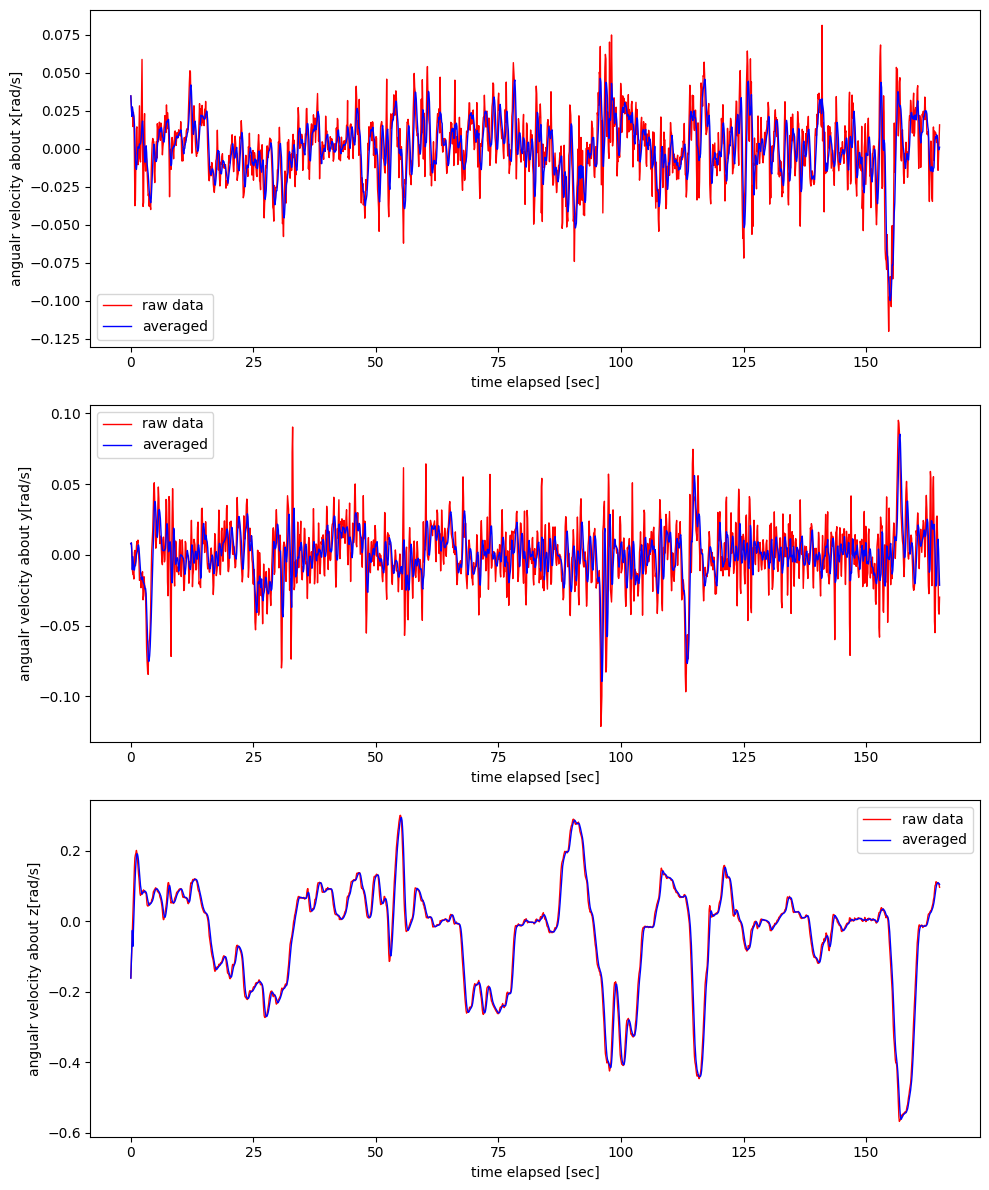

In [105]:
visualize_data_to_compare(data.IMU_outputs[:, 3:], angle_vel_mean, ang_y_labels)

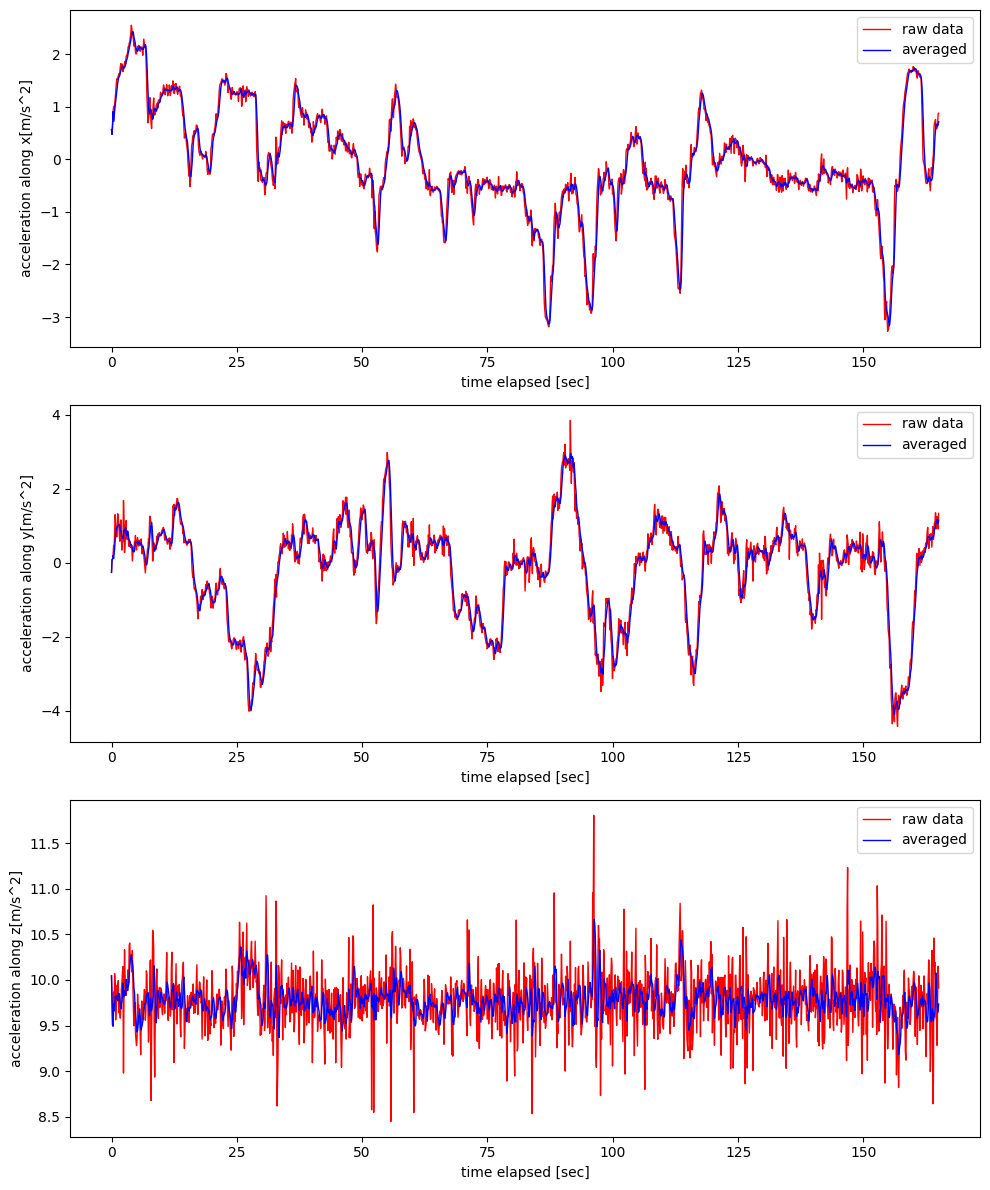

In [106]:
visualize_data_to_compare(data.IMU_outputs[:, :3], linear_acc_mean, acc_y_labels)

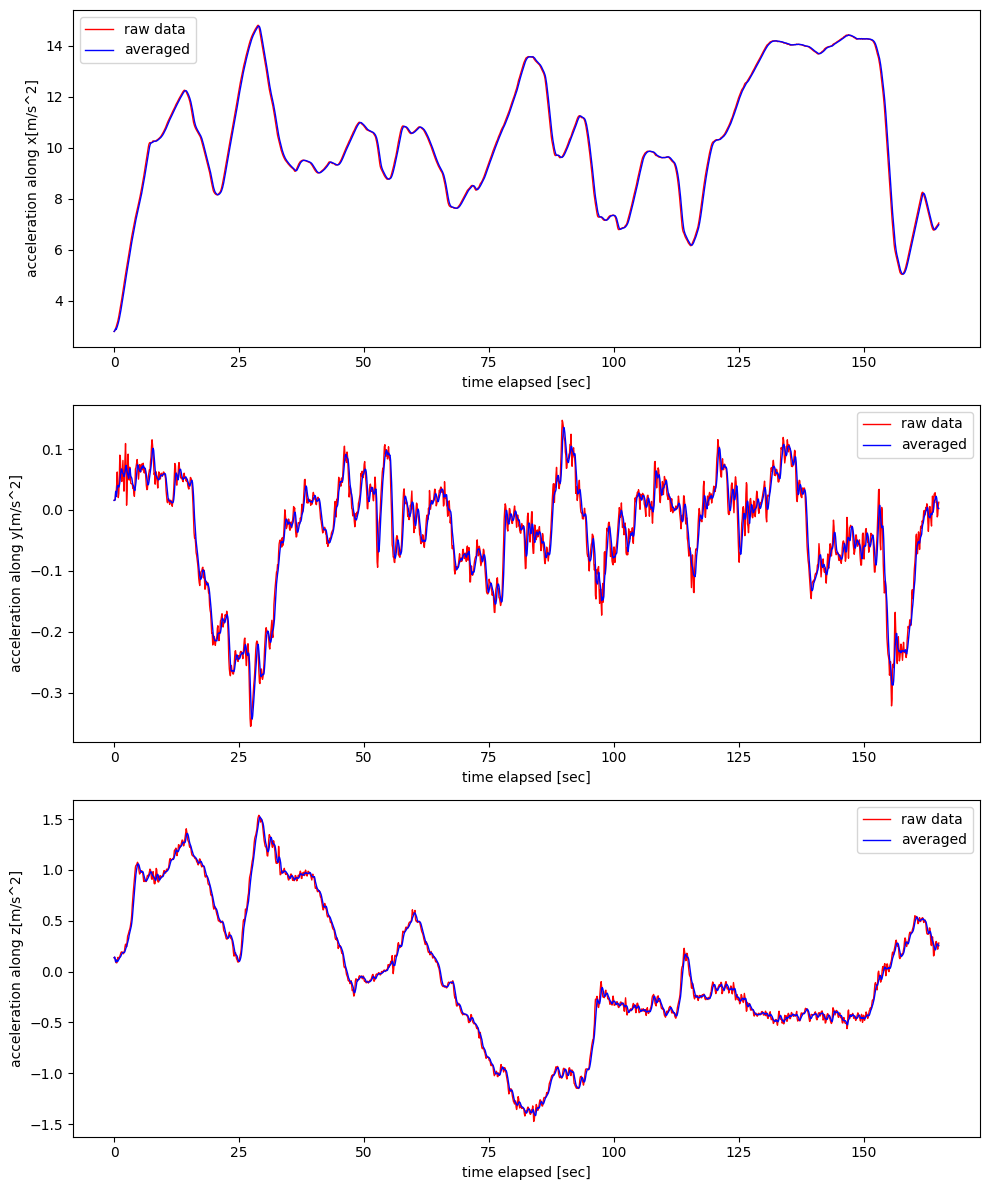

In [103]:
visualize_data_to_compare(data.INS_velocities, linear_vel_mean, acc_y_labels)

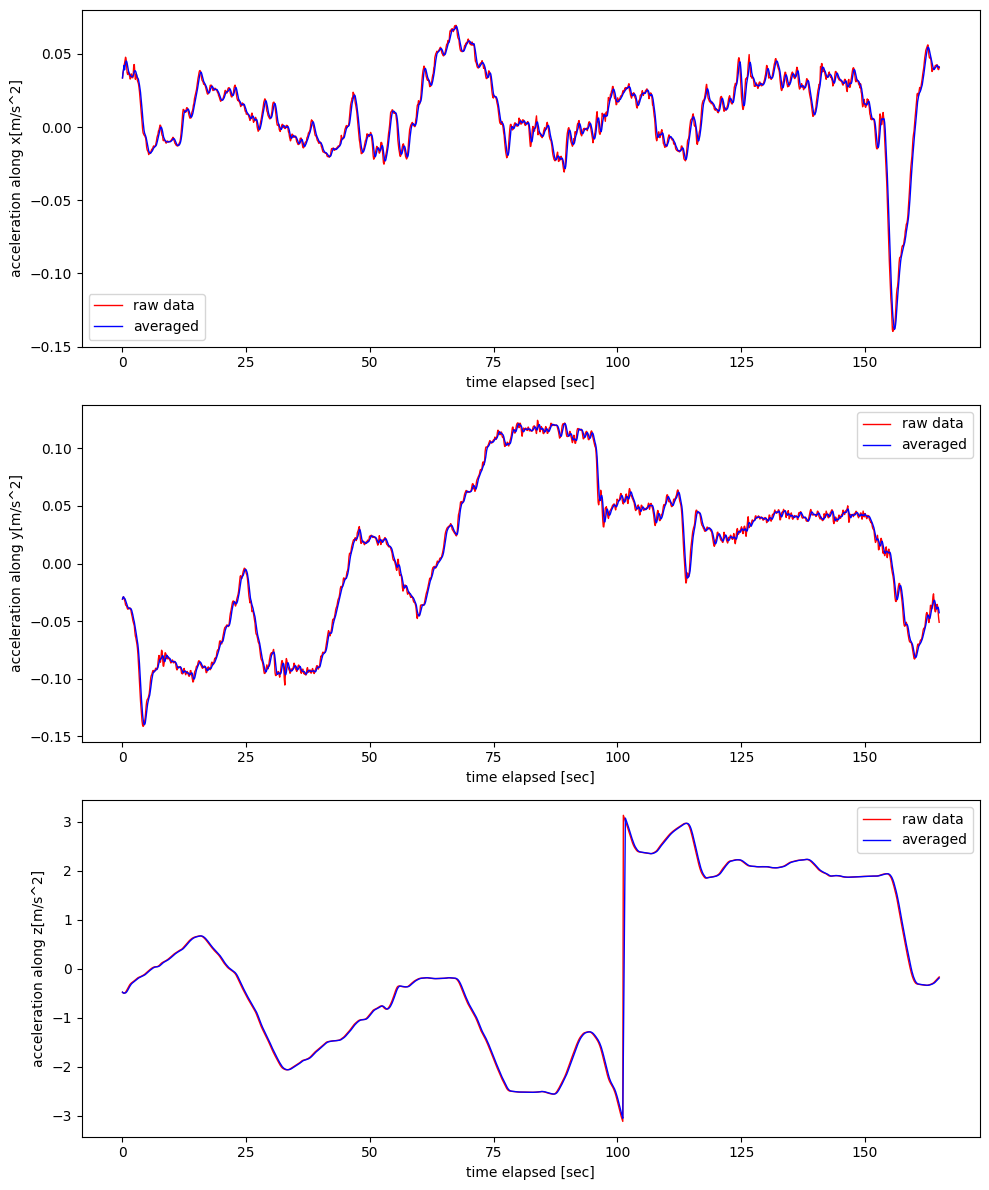

In [104]:
visualize_data_to_compare(data.INS_angles, angle_mean, acc_y_labels)